# ECSE 415 – Course Project: Classification, Detection & Localization
**Due:** April 9, 2026, 11:59 PM

## Team Members
| # | Name | McGill ID | 
|---|------|-----------|
| 1 | Tarek Namani |261085655 |
| 2 | Hugues Salmon | 261238982 |
| 3 | Sanad Abu Baker | 261143797 |
| 4 | Paul Litscher| 261167726 |
| 5 | Boris Vassilev | |


# Section 0 – Imports & Configuration

In [2]:
dataset_root = "data/"
test_root = dataset_root + "test/test/"
train_root = dataset_root + "train/train/"

import os
import random
import shutil
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
import torchvision.transforms.functional as TF

import sklearn
import skimage
from skimage.feature import hog
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## Dependencies

### External dependencies used :
- torch: 2.11.0+cu128
- torchvision: 0.26.0+cu128
- cv2: 4.13.0
- sklearn: 1.8.0
- skimage: 0.26.0
- numpy: 2.4.4
- pandas: 3.0.1
- matplotlib: 3.10.8

In [46]:
# Quick dependency check for this kernel
print("torch:", torch.__version__)
print("torchvision:", __import__("torchvision").__version__)
print("cv2:", cv2.__version__)
print("sklearn:", sklearn.__version__)
print("skimage:", skimage.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)

torch: 2.11.0+cu128
torchvision: 0.26.0+cu128
cv2: 4.13.0
sklearn: 1.8.0
skimage: 0.26.0
numpy: 2.4.4
pandas: 3.0.1
matplotlib: 3.10.8


# Section 1 – Data Loading


- Load the Dogs vs. Cats dataset, assign labels, and create an 80/20 train/internal-test split.
- The internal split is built **only** from Kaggle's **labeled** training folder (`data/train/train/`). Kaggle's `data/test/test/` images are **unlabeled** and are **not** used for training Options A–C (only for final submission scoring later).
- All three classifiers will consume the output arrays from this section.


In [3]:
def _list_class_images(class_dir):
    """Only labeled train images (Kaggle naming: class.<id>.jpg). Ignores junk like .DS_Store."""
    files = []
    for name in os.listdir(class_dir):
        if not name.lower().endswith((".jpg", ".jpeg")):
            continue
        parts = name.split(".")
        if len(parts) < 3:
            continue
        try:
            int(parts[1])
        except ValueError:
            continue
        files.append(os.path.join(class_dir, name))
    return sorted(files)


def load_dataset(directory):
    dog_root = os.path.join(directory, "dogs")
    cat_root = os.path.join(directory, "cats")

    dog_files = _list_class_images(dog_root)
    cat_files = _list_class_images(cat_root)
    num_dogs = len(dog_files)
    num_cats = len(cat_files)

    train_dogs, test_dogs = [], []
    train_cats, test_cats = [], []

    # Split the dataset into train and test sets based on the specified ratio (80% train, 20% test)
    dog_indices = list(range(num_dogs))
    test_dogs_indices = set(dog_indices[int(0.8 * num_dogs) :])

    cat_indices = list(range(num_cats))
    test_cats_indices = set(cat_indices[int(0.8 * num_cats) :])

    # Append the respective paths to the train/test lists based on the indices
    for path in dog_files:
        number = int(os.path.basename(path).split(".")[1])
        if number in test_dogs_indices:
            test_dogs.append(path)
        else:
            train_dogs.append(path)

    for path in cat_files:
        number = int(os.path.basename(path).split(".")[1])
        if number in test_cats_indices:
            test_cats.append(path)
        else:
            train_cats.append(path)

    return (train_dogs, test_dogs), (train_cats, test_cats)


def create_splits(train_dogs, test_dogs, train_cats, test_cats):
    """Build a fresh internal train/val split from Kaggle *labeled* train only.

    Always removes `internal_split/` first so re-running the notebook cannot duplicate
    files or leave stale images in train (which would inflate counts and can overlap splits).
    """
    split_root = Path(dataset_root) / "internal_split"
    if split_root.exists():
        shutil.rmtree(split_root)

    (split_root / "train" / "cats").mkdir(parents=True, exist_ok=True)
    (split_root / "train" / "dogs").mkdir(parents=True, exist_ok=True)
    (split_root / "test" / "cats").mkdir(parents=True, exist_ok=True)
    (split_root / "test" / "dogs").mkdir(parents=True, exist_ok=True)

    for file in train_dogs:
        shutil.copy(file, split_root / "train" / "dogs" / os.path.basename(file))
    for file in test_dogs:
        shutil.copy(file, split_root / "test" / "dogs" / os.path.basename(file))
    for file in train_cats:
        shutil.copy(file, split_root / "train" / "cats" / os.path.basename(file))
    for file in test_cats:
        shutil.copy(file, split_root / "test" / "cats" / os.path.basename(file))

    train_names = {p.name for p in (split_root / "train" / "cats").glob("*.jpg")} | {
        p.name for p in (split_root / "train" / "dogs").glob("*.jpg")
    }
    test_names = {p.name for p in (split_root / "test" / "cats").glob("*.jpg")} | {
        p.name for p in (split_root / "test" / "dogs").glob("*.jpg")
    }
    overlap = train_names & test_names
    if overlap:
        raise RuntimeError(
            f"internal_split leak: {len(overlap)} filenames appear in both train and test (e.g. {next(iter(overlap))})"
        )
    if len(train_names) != len(train_dogs) + len(train_cats):
        raise RuntimeError("internal_split train count mismatch after copy")
    if len(test_names) != len(test_dogs) + len(test_cats):
        raise RuntimeError("internal_split test count mismatch after copy")


(train_dogs, test_dogs), (train_cats, test_cats) = load_dataset(train_root)
create_splits(train_dogs, test_dogs, train_cats, test_cats)

print(f"Number of training dogs: {len(train_dogs)}")
print(f"Number of testing dogs: {len(test_dogs)}")
print(f"Number of training cats: {len(train_cats)}")
print(f"Number of testing cats: {len(test_cats)}")

Number of training dogs: 8383
Number of testing dogs: 1596
Number of training cats: 8390
Number of testing cats: 1631


# Section 2 – Option A: Feature-Based Classifier (HOG + SVM)

### 2.1 Method Overview

For Option A, we use a classical feature-based pipeline with **Histogram of Oriented Gradients (HOG)** and a **Support Vector Machine (SVM)** for cat-vs-dog classification.

HOG converts each image into a compact descriptor based on local gradient orientations, and the SVM learns a binary decision boundary from those descriptors.

This section provides a lightweight non-deep-learning baseline to compare against Option B and Option C.

### 2.2 Data Preparation & HOG Features

In [4]:
# Paths created in Section 1
optA_train_dir = Path(dataset_root) / "internal_split" / "train"
optA_test_dir = Path(dataset_root) / "internal_split" / "test"

# HOG configuration
hog_img_size = (128, 128)
hog_params = {
    "orientations": 9,
    "pixels_per_cell": (8, 8),
    "cells_per_block": (2, 2),
    "block_norm": "L2-Hys",
}

def collect_image_paths(split_dir):
    image_paths, labels = [], []
    class_to_label = {"cats": 0, "dogs": 1}

    for class_name, label in class_to_label.items():
        class_dir = split_dir / class_name
        for p in sorted(class_dir.glob("*.jpg")):
            image_paths.append(p)
            labels.append(label)

    return image_paths, np.array(labels)

def extract_hog_features(image_paths, img_size=hog_img_size, params=hog_params):
    features = []
    for p in image_paths:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, img_size, interpolation=cv2.INTER_AREA)
        feat = hog(
            img,
            orientations=params["orientations"],
            pixels_per_cell=params["pixels_per_cell"],
            cells_per_block=params["cells_per_block"],
            block_norm=params["block_norm"],
            feature_vector=True,
        )
        features.append(feat)
    return np.array(features)

train_paths, y_train = collect_image_paths(optA_train_dir)
test_paths, y_test = collect_image_paths(optA_test_dir)

X_train = extract_hog_features(train_paths)
X_test = extract_hog_features(test_paths)

print(f"Option A train samples: {len(y_train)}")
print(f"Option A test samples:  {len(y_test)}")
print(f"HOG feature dimension:  {X_train.shape[1]}")

Option A train samples: 16773
Option A test samples:  3227
HOG feature dimension:  8100


### 2.3 SVM Training Setup

In [5]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(C=1.0, class_weight="balanced", random_state=42, max_iter=20000)),
])

start_train = time.time()
svm_pipeline.fit(X_train, y_train)
train_time_sec = time.time() - start_train

print(f"SVM training complete in {train_time_sec:.2f} s")

SVM training complete in 623.36 s


### 2.4 Results on Internal Test Set

Option A (HOG + SVM) metrics
Accuracy : 0.6464
Precision: 0.6423
Recall   : 0.6435
F1-score : 0.6429
Train time (s): 623.36
Inference time for 3227 images (s): 0.06


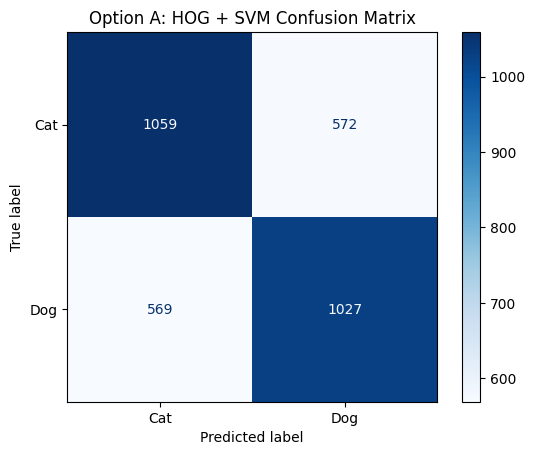

In [6]:
start_infer = time.time()
y_pred = svm_pipeline.predict(X_test)
infer_time_sec = time.time() - start_infer

acc_optA = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")

print("Option A (HOG + SVM) metrics")
print(f"Accuracy : {acc_optA:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"Train time (s): {train_time_sec:.2f}")
print(f"Inference time for {len(y_test)} images (s): {infer_time_sec:.2f}")

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Cat", "Dog"]).plot(cmap="Blues")
plt.title("Option A: HOG + SVM Confusion Matrix")
plt.show()

### 2.5 Discussion (Strengths, Failures, Cost)

**Performance:** On the internal test split, HOG + SVM reached about **64.5% accuracy** (F1 ≈ **0.65**), with precision and recall close together, indicating the classifier is not strongly biased toward predicting only one class.

**Confusion matrix interpretation:** Misclassifications are similar for both directions (cats predicted as dogs vs dogs predicted as cats), suggesting failures are not dominated by a single label asymmetry, but by cases where local edge/gradient patterns are ambiguous.

**Why HOG + SVM can struggle here:** HOG mainly encodes edge/gradient structure over fixed spatial cells. It can miss global semantic cues and fine texture patterns that CNNs learn, and it can be sensitive to **pose changes**, **cropping**, **occlusion**, **background clutter**, and **lighting** when the animal does not produce a consistent edge pattern.

**Computational trade-offs:** Training took on the order of **~10 minutes** in our run, while inference on the full internal test set was extremely fast (**~0.06 s** for 3227 images). This makes HOG + SVM attractive for lightweight deployment and fast batch scoring, even if accuracy is lower than deep models.

**Takeaway:** Option A provides a meaningful classical baseline: it is interpretable and efficient at test time, but likely underperforms CNN approaches on this dataset—consistent with expectations for handcrafted features on complex natural images.

# Section 3 – Option B: Appearance-Based Classifier (PCA + Classifier)

### 3.1 Method Overview

We use a **PCA + SVM** pipeline.

**How it works:**
1. Every image is resized to a fixed resolution and flattened into a 1-D pixel vector.
2. PCA is fit on the training set. It finds the directions of maximum variance across all images — the *principal components*. Each component looks like a ghostly, blurred prototype of the visual patterns shared by many images.
3. Every image (train and test) is projected onto the top-k principal components, giving a compact k-dimensional descriptor.
4. An SVM is trained on those low-dimensional descriptors.


### 3.2 Data Preparation

In [7]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# Configuration
optB_train_dir = Path(dataset_root) / "internal_split" / "train"
optB_test_dir  = Path(dataset_root) / "internal_split" / "test"

PCA_IMG_SIZE = (64, 64)   # resize before flattening (smaller = faster PCA)
N_COMPONENTS = 150        # number of principal components to keep

def load_flat_pixels(split_dir, img_size=PCA_IMG_SIZE):
    """Read all images in split_dir/{cats,dogs}, resize, convert to
    grayscale, and return (X, y) where X has shape (N, H*W)."""
    class_to_label = {"cats": 0, "dogs": 1}
    X_list, y_list = [], []

    for class_name, label in class_to_label.items():
        class_dir = split_dir / class_name
        for p in sorted(class_dir.glob("*.jpg")):
            img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, img_size, interpolation=cv2.INTER_AREA)
            X_list.append(img.flatten().astype(np.float32))
            y_list.append(label)

    return np.array(X_list), np.array(y_list)

X_train_raw, y_train_B = load_flat_pixels(optB_train_dir)
X_test_raw,  y_test_B  = load_flat_pixels(optB_test_dir)

print(f"Option B train samples : {X_train_raw.shape[0]}")
print(f"Option B test samples  : {X_test_raw.shape[0]}")
print(f"Raw pixel dimension    : {X_train_raw.shape[1]}  ({PCA_IMG_SIZE[0]}x{PCA_IMG_SIZE[1]} grayscale)")

Option B train samples : 16773
Option B test samples  : 3227
Raw pixel dimension    : 4096  (64x64 grayscale)


### 3.3 PCA: Fit, Project, Explained Variance

PCA reduced 4096-D → 150-D
Variance explained by top 150 components: 89.8%


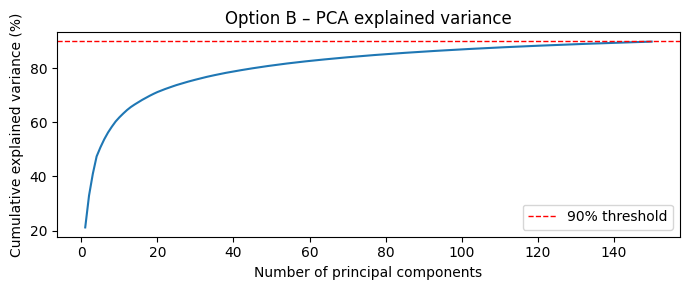

In [8]:
# 1. Zero-mean the data (required before PCA)
scaler_B = StandardScaler(with_std=False)   # subtract mean only
X_train_centered = scaler_B.fit_transform(X_train_raw)
X_test_centered  = scaler_B.transform(X_test_raw)

# 2. Fit PCA on training set only (never on test data)
pca = PCA(n_components=N_COMPONENTS, whiten=True, random_state=42)
X_train_pca = pca.fit_transform(X_train_centered)
X_test_pca  = pca.transform(X_test_centered)

print(f"PCA reduced {X_train_raw.shape[1]}-D → {N_COMPONENTS}-D")
print(f"Variance explained by top {N_COMPONENTS} components: "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")

# 3. Explained variance curve
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(1, N_COMPONENTS + 1), cumvar, linewidth=1.5)
ax.axhline(90, color="red", linestyle="--", linewidth=1, label="90% threshold")
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance (%)")
ax.set_title("Option B – PCA explained variance")
ax.legend()
plt.tight_layout()
plt.show()

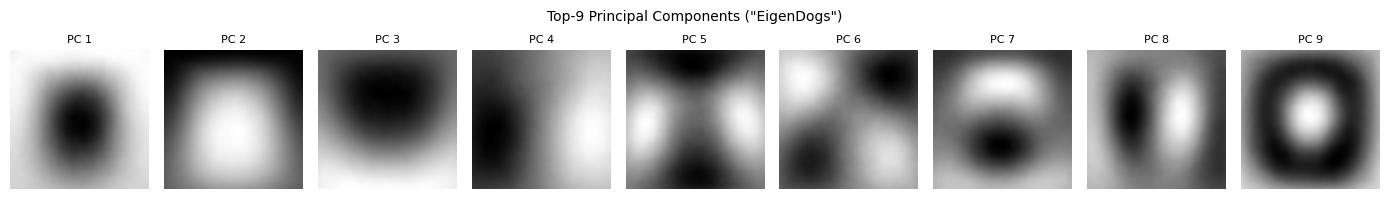

In [9]:
# visualize eigendogs
# Visualise the top-9 principal components ("EigenDogs")
n_show = 9
fig, axes = plt.subplots(1, n_show, figsize=(14, 2))
for idx, ax in enumerate(axes):
    component = pca.components_[idx].reshape(PCA_IMG_SIZE)
    # Normalise to [0,1] for display
    component = (component - component.min()) / (component.max() - component.min() + 1e-8)
    ax.imshow(component, cmap="gray")
    ax.set_title(f"PC {idx+1}", fontsize=8)
    ax.axis("off")
fig.suptitle('Top-9 Principal Components ("EigenDogs")', fontsize=10)
plt.tight_layout()
plt.show()

### 3.4: SVM Training on PCA Features

In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C":     [0.1, 1.0, 10.0],
    "gamma": ["scale", 0.01],
}

svm_B_base = SVC(kernel="rbf", class_weight="balanced", random_state=42)

start_train_B = time.time()
grid_search = GridSearchCV(svm_B_base, param_grid, cv=3,
                           scoring="accuracy", n_jobs=-1, verbose=1)
grid_search.fit(X_train_pca, y_train_B)
train_time_B = time.time() - start_train_B

svm_B = grid_search.best_estimator_
print(f"\nBest params : {grid_search.best_params_}")
print(f"CV accuracy : {grid_search.best_score_:.4f}")
print(f"Training time (including grid search): {train_time_B:.2f} s")

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best params : {'C': 1.0, 'gamma': 0.01}
CV accuracy : 0.6676
Training time (including grid search): 103.29 s


### 3.5: Test Results

Option B (PCA + SVM) metrics
Accuracy : 0.6861
Precision: 0.6834
Recall   : 0.6805
F1-score : 0.6819
Train time (s)     : 103.29
Inference time (s) : 2.6246  for 3227 samples


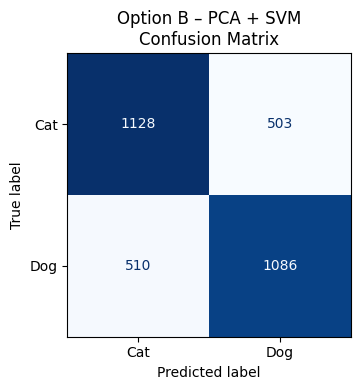

In [11]:
start_infer_B = time.time()
y_pred_B = svm_B.predict(X_test_pca)
infer_time_B = time.time() - start_infer_B

acc_optB = accuracy_score(y_test_B, y_pred_B)
precision_B, recall_B, f1_B, _ = precision_recall_fscore_support(
    y_test_B, y_pred_B, average="binary"
)

print("Option B (PCA + SVM) metrics")
print(f"Accuracy : {acc_optB:.4f}")
print(f"Precision: {precision_B:.4f}")
print(f"Recall   : {recall_B:.4f}")
print(f"F1-score : {f1_B:.4f}")
print(f"Train time (s)     : {train_time_B:.2f}")
print(f"Inference time (s) : {infer_time_B:.4f}  for {len(y_test_B)} samples")

# Confusion matrix
cm_B = confusion_matrix(y_test_B, y_pred_B)
disp_B = ConfusionMatrixDisplay(confusion_matrix=cm_B,
                                display_labels=["Cat", "Dog"])
fig, ax = plt.subplots(figsize=(4, 4))
disp_B.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Option B – PCA + SVM\nConfusion Matrix")
plt.tight_layout()
plt.show()

# Section 4 – Option C: Deep Learning Classifier (CNN)

## 4.1 Method overview 

The Resnet50 model was used for our CNN approach. This is a pretrained model, and contains pre-trained features. To make the most out of this model, we will test different approaches by "freezing" different layers of the model and seeing differences in performance, and training times

Additionally, we will be seeing the impacts of adding pre-processing (augmenting) steps to our training data, and evaluating whether or not the increase in variety of images helps increase accuracy

In [ ]:
LOAD_TRAINIED_MODELS = False

## 4.2 Non-augmented approaches

In [ ]:
gpu = torch.cuda.is_available()
device = torch.device("cuda" if gpu else "cpu")

base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset_noaug = ImageFolder(dataset_root + 'internal_split/train/', transform=base_transform)
test_dataset_noaug = ImageFolder(dataset_root + 'internal_split/test/', transform=base_transform)

train_loader_noaug = DataLoader(train_dataset_noaug, batch_size=64, shuffle=True, num_workers=4)
test_loader_noaug = DataLoader(test_dataset_noaug, batch_size=64, shuffle=False, num_workers=4)

def train_head_only():
    global criterion, optimizer
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    model.fc = nn.Linear(model.fc.in_features, 2)
    
    if LOAD_TRAINIED_MODELS and os.path.exists('resnet50_noaug_progressive_head.pth'):
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
        return model
    
    model.to(device)
    
    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False
    # Uunfreeze the final fully connected layer
    for param in model.fc.parameters():
        param.requires_grad = True

    model = model.to(device) 
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    return model

def train_intermediate_layers(model):
    global optimizer, criterion
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer3.parameters():
        param.requires_grad = True
    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    model = model.to(device) 
    return model

def freeze_model(reset_model, loaded_model=None):
    global optimizer, criterion
    
    # If we have already trained and saved, load the trained model
    if LOAD_TRAINIED_MODELS and os.path.exists('resnet50_noaug.pth'):
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Linear(model.fc.in_features, 2)
        model.load_state_dict(torch.load('resnet50_noaug.pth'))
        model = model.to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
        return model
    
    # If we are starting fresh, load the pretrained ResNet50 and modify the final layer
    if reset_model:
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Linear(model.fc.in_features, 2)
        model = model.to(device)
    

    # Else we are resuming from a previous stage, so use the provided model with some layers already trained, freeze everything but layer4 and the head
    else:
        model = loaded_model
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    return model       

def fine_tune(reset_model, loaded_model=None):
    global optimizer, criterion

    # If we have already trained and saved, load the trained model
    if LOAD_TRAINIED_MODELS and os.path.exists('resnet50_noaug_fine_tune.pth'):
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Linear(model.fc.in_features, 2)
        model.load_state_dict(torch.load('resnet50_noaug_fine_tune.pth'))
        model = model.to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=1e-5)
        return model
    
    
    if reset_model:
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Linear(model.fc.in_features, 2)
        model = model.to(device)
    else:
        model = loaded_model
    for param in model.parameters():
        param.requires_grad = True 
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-5)
    return model

def plot_confusion_matrix(all_labels, all_preds, model_name, val_acc):
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Cat', 'Dog'])
    disp.plot(cmap='Blues')
    plt.title(f'Option C - {model_name}\nVal Acc: {val_acc:.2f}%')
    plt.show()

def train_epoch(model, train_loader): 
    model.train()
    train_loss, train_correct = 0.0, 0
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
            
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
            
        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()
        
    return 100 * train_correct / len(train_loader.dataset)
    
def test_model(model, test_loader):
        model.eval()
        val_correct, all_preds, all_labels = 0, [], []
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()
                all_preds.extend(outputs.argmax(1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        return (100 * val_correct / len(test_loader.dataset)), all_preds, all_labels

def train_and_test_baseline(train_loader, test_loader, model_name, model, epochs=3):
    best_val_acc = 0.0
    start_time = time.time()
    
    for epoch in range(epochs):
        # train
        if not LOAD_TRAINIED_MODELS :
            train_acc = train_epoch(model, train_loader)
        
        # validate
        val_acc, all_preds, all_labels = test_model(model, test_loader)
        
        if LOAD_TRAINIED_MODELS:
            print(f"Loaded {model_name} with val acc: {val_acc:.1f}%")
            plot_confusion_matrix(all_labels, all_preds, model_name, val_acc)
            return val_acc
            
        
        print(f'{model_name} Epoch {epoch+1}/{epochs}: '
              f'Train: {train_acc:.1f}% | Val: {val_acc:.1f}%')
        
        if val_acc > best_val_acc and not LOAD_TRAINIED_MODELS:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'{model_name}.pth')
    
    runtime = time.time() - start_time
    if not LOAD_TRAINIED_MODELS:
        print(f'{model_name} complete: {best_val_acc:.1f}% in {runtime/60:.1f} min')
    
    # plot confusion matrix
    plot_confusion_matrix(all_labels, all_preds, model_name, best_val_acc)
    
    return best_val_acc

def train_and_test_progressive_unfreeze(train_loaders, test_loaders, model_name, epochs_per_stage=3):
    best_val_acc = 0.0
    model = train_head_only()
    start_time = time.time()
    train_loader = train_loaders[0]
    test_loader = test_loaders[0]
    
    if LOAD_TRAINIED_MODELS and os.path.exists(f'{model_name}_fine_tune.pth'):
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        model.load_state_dict(torch.load(f'{model_name}_fine_tune.pth'))
        model.to(device)
        val_acc, all_preds, all_labels = test_model(model, test_loader)
        plot_confusion_matrix(all_labels, all_preds, model_name, val_acc) 
        return 
    
    for stage in range(epochs_per_stage):
        train_acc = train_epoch(model, train_loader)
        
        # validate
        val_acc, all_preds, all_labels = test_model(model, test_loader)
        
        print(f'{model_name}_head Epoch {stage+1}/{epochs_per_stage}: 'f'Train: {train_acc:.1f}% | Val: {val_acc:.1f}%')
            
    model = freeze_model(reset_model=False, loaded_model=model)
    for stage in range(epochs_per_stage):
        train_acc = train_epoch(model, train_loader)
        # validate
        val_acc, all_preds, all_labels = test_model(model, test_loader)
        
        print(f'{model_name}_head_layer4 Epoch {stage+1}/{epochs_per_stage}: 'f'Train: {train_acc:.1f}% | Val: {val_acc:.1f}%')
            
    model = train_intermediate_layers(model)
    train_loader = train_loaders[1]
    test_loader = test_loaders[1]
    for stage in range(epochs_per_stage):   
        train_acc = train_epoch(model, train_loader)
        
        # validate
        val_acc, all_preds, all_labels = test_model(model, test_loader)
        
        print(f'{model_name}_intermediate Epoch {stage+1}/{epochs_per_stage}: 'f'Train: {train_acc:.1f}% | Val: {val_acc:.1f}%')
            
    model = fine_tune(reset_model=False, loaded_model=model)     
    for stage in range(epochs_per_stage):
        train_acc = train_epoch(model, train_loader)
        
        # validate
        val_acc, all_preds, all_labels = test_model(model, test_loader)
        
        print(f'{model_name}_fine_tune Epoch {stage+1}/{epochs_per_stage}: 'f'Train: {train_acc:.1f}% | Val: {val_acc:.1f}%')
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'{model_name}_fine_tune.pth')
        
    runtime = time.time() - start_time
    print(f'{model_name} complete: {best_val_acc:.1f}% in {runtime/60:.1f} min')
    plot_confusion_matrix(all_labels, all_preds, model_name, best_val_acc)   


Baseline (no transforms):
resnet50_noaug Epoch 1/3: Train: 98.4% | Val: 99.2%
resnet50_noaug Epoch 2/3: Train: 99.7% | Val: 99.3%
resnet50_noaug Epoch 3/3: Train: 99.9% | Val: 99.3%
resnet50_noaug complete: 99.3% in 2.5 min


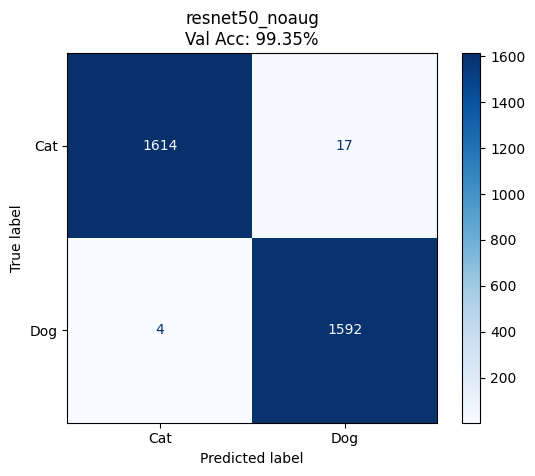

In [ ]:
# Train only the head and layer 4
print("Baseline (no transforms):")
model = freeze_model(reset_model=True)

acc_noaug = train_and_test_baseline(train_loader_noaug, test_loader_noaug,'resnet50_noaug', model)

No freeze (no transforms):
resnet50_noaug_fine_tune Epoch 1/5: Train: 95.6% | Val: 99.4%
resnet50_noaug_fine_tune Epoch 2/5: Train: 99.3% | Val: 99.5%
resnet50_noaug_fine_tune Epoch 3/5: Train: 99.6% | Val: 99.4%
resnet50_noaug_fine_tune Epoch 4/5: Train: 99.8% | Val: 99.5%
resnet50_noaug_fine_tune Epoch 5/5: Train: 99.9% | Val: 99.5%
resnet50_noaug_fine_tune complete: 99.5% in 5.8 min


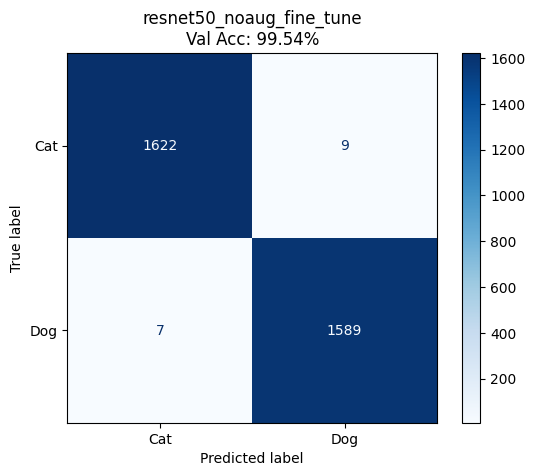

In [ ]:
# Fine-tuning with all layers unfrozen
print("No freeze (no transforms):")
model = fine_tune(reset_model=True)

acc_noaug = train_and_test_baseline(train_loader_noaug, test_loader_noaug, 'resnet50_noaug_fine_tune', model, 5)

Progressive unfreeze (no transforms):
resnet50_noaug_progressive_head Epoch 1/3: Train: 90.1% | Val: 98.6%
resnet50_noaug_progressive_head Epoch 2/3: Train: 98.3% | Val: 98.9%
resnet50_noaug_progressive_head Epoch 3/3: Train: 98.7% | Val: 99.1%
resnet50_noaug_progressive_head_layer4 Epoch 1/3: Train: 99.1% | Val: 99.2%
resnet50_noaug_progressive_head_layer4 Epoch 2/3: Train: 99.9% | Val: 99.2%
resnet50_noaug_progressive_head_layer4 Epoch 3/3: Train: 100.0% | Val: 99.4%
resnet50_noaug_progressive_intermediate Epoch 1/3: Train: 99.8% | Val: 99.3%
resnet50_noaug_progressive_intermediate Epoch 2/3: Train: 99.8% | Val: 99.3%
resnet50_noaug_progressive_intermediate Epoch 3/3: Train: 100.0% | Val: 99.3%
resnet50_noaug_progressive_fine_tune Epoch 1/3: Train: 100.0% | Val: 99.3%
resnet50_noaug_progressive_fine_tune Epoch 2/3: Train: 100.0% | Val: 99.3%
resnet50_noaug_progressive_fine_tune Epoch 3/3: Train: 100.0% | Val: 99.3%
resnet50_noaug_progressive complete: 99.3% in 11.1 min


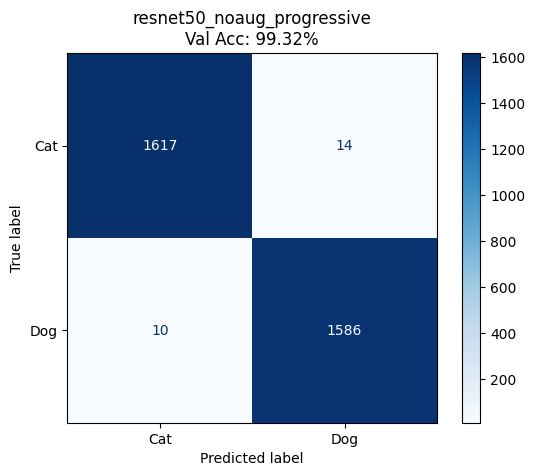

In [ ]:
# Progressively unfreeze layers
print("Progressive unfreeze (no transforms):")

acc_noaug = train_and_test_progressive_unfreeze([train_loader_noaug, train_loader_noaug], [test_loader_noaug, test_loader_noaug], 'resnet50_noaug_progressive', 3)

## 4.2 Adding pre-processing

Having seen that progressively un-freezing layers is optimal, we will be proceeding with that method moving forward

Progressive unfreeze (with transforms):


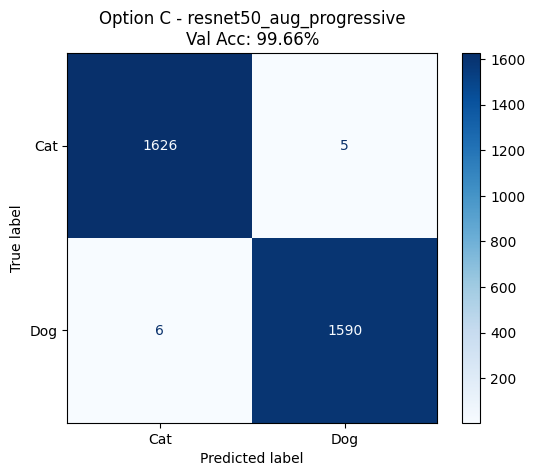

In [58]:
# Stage 1+2
# Define mild transfors, that allow the model to learn stable features without overwhelming it with too much variability early on
mild_transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Stage 3+4
# Define stronger thransforms that force the model to learn more robust features and generalize better, but may be too much for early training stages
strong_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.RandomGrayscale(p=0.3), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1)
])

train_loader_mild = DataLoader(ImageFolder(dataset_root + 'internal_split/train/', transform=mild_transform), batch_size=16, shuffle=True, num_workers=6)
train_loader_strong = DataLoader(ImageFolder(dataset_root + 'internal_split/train/', transform=strong_transform), batch_size=32, shuffle=True, num_workers=6)

print("Progressive unfreeze (with transforms):")
acc_noaug = train_and_test_progressive_unfreeze([train_loader_mild, train_loader_strong], [test_loader_noaug, test_loader_noaug], 'resnet50_aug_progressive', 3)

# Section 5 – Evaluation: Confusion Matrices & Model Comparison

### Method Comparison Discussion

| Metric | Option A  | Option B | Option C (progressive + aug) |
|--------|--------------------------|----------------|----------------|
| Accuracy | 64.64 | 68.87 |99.66 |
| Training Time (mins)| 10.3 | 1.7 | 12.2 |
| Notes | CPU only | CPU only | GPU-accelerated |


# Section 6 – Kaggle Competition Submission

In [8]:
kaggle_dataset_root = dataset_root + "test/test"

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)
model.load_state_dict(torch.load('resnet50_aug_progressive_fine_tune.pth'))
model.to(device)
model.eval()

# Predict on ALL test images directly
test_files = os.listdir(kaggle_dataset_root)
predictions = [0] * len(test_files)  # Pre-allocate list for 5000 predictions

with torch.no_grad():
    for img_path in test_files:
        # Load + transform single image
        image = Image.open(kaggle_dataset_root + "/" +  img_path).convert('RGB')
        image = base_transform(image).unsqueeze(0).to(device)
        
        output = model(image)
        pred_label = output.argmax(dim=1).cpu().item()
 
        img_id = int(img_path.replace('test', '').replace('.jpg', ''))
        predictions[img_id - 1] = [img_id, pred_label]

# Save CSV
submission_df = pd.DataFrame(predictions, columns=['id', 'label'])
submission_df.to_csv('submission.csv', index=False)
print(f"{len(submission_df)} predictions saved")
print(submission_df.head())

5000 predictions saved
   id  label
0   1      1
1   2      1
2   3      0
3   4      1
4   5      1


# Section 7 – Part 2: Detection & Localization (Stanford Dogs Dataset)

## Model Wrapper (Classification → Detection Bridge)

We wrap the trained ResNet50 classifier from Section 4 into a single, **detector-agnostic** interface.  
The wrapper exposes one method:

```
score_patches(patches: list[np.ndarray]) -> np.ndarray
```

**Pipeline per patch:**  `BGR image → RGB → Resize(224×224) → ToTensor → Normalize → model.eval() → softmax → dog probability`

The normalization and architecture match **exactly** what was used during training so that the detector code never needs to know classifier internals.

In [9]:
class DogDetectorWrapper:

    # Provides a single score_patches() API for the detection pipeline.

    DOG_CLASS_IDX = 1  # ImageFolder alphabetical: cats=0, dogs=1

    def __init__(self, model_path="resnet50_aug_progressive_fine_tune.pth", device=None):
        if device is None:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.device = device

        self.model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.model.fc = nn.Linear(self.model.fc.in_features, 2)
        self.model.load_state_dict(
            torch.load(model_path, map_location=self.device, weights_only=False)
        )
        self.model.to(self.device)
        self.model.eval()

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225]),
        ])

    @torch.no_grad()
    def score_patches(self, patches: list) -> np.ndarray:
        """
        Score image patches for 'dog' confidence.

        Params
        patches: BGR uint8 images of arbitrary size.

        Returns
        np.ndarray of shape (len(patches),) with dog probabilities in [0, 1].
        """
        if len(patches) == 0:
            return np.array([], dtype=np.float32)

        tensors = []
        for patch in patches:
            rgb = cv2.cvtColor(patch, cv2.COLOR_BGR2RGB)
            tensors.append(self.transform(rgb))

        batch = torch.stack(tensors).to(self.device)
        logits = self.model(batch)
        probs = torch.softmax(logits, dim=1)
        return probs[:, self.DOG_CLASS_IDX].cpu().numpy()


# Instantiate the wrapper (loads saved weights from Section 4)
dog_wrapper = DogDetectorWrapper()
print("DogDetectorWrapper ready on", dog_wrapper.device)

DogDetectorWrapper ready on cuda


## Stanford Dogs Dataset Ingestion

The Stanford Dogs dataset provides full-scene images with PASCAL-VOC-style XML annotations containing bounding boxes.

**Convention adopted:** all boxes are stored as `(x_min, y_min, x_max, y_max)`.

Helper functions:
| Function | Purpose |
|---|---|
| `load_image(path)` | Read image as BGR `np.ndarray` |
| `load_annotation(path)` | Parse XML → `list[Box]` |
| `clip_box_to_image(box, w, h)` | Clamp to image bounds |
| `draw_boxes(image, boxes, …)` | Overlay boxes for visualization |
| `load_stanford_dogs_dataset(…)` | Full loader returning `{image, image_id, gt_boxes, breed}` dicts |

In [ ]:
import xml.etree.ElementTree as ET
from collections import namedtuple
import tarfile, urllib.request

Box = namedtuple("Box", ["x_min", "y_min", "x_max", "y_max"])

STANFORD_DOGS_ROOT = os.path.join(dataset_root, "stanford_dogs")
STANFORD_DOGS_IMAGES = os.path.join(STANFORD_DOGS_ROOT, "Images")
STANFORD_DOGS_ANNOTATIONS = os.path.join(STANFORD_DOGS_ROOT, "Annotation")

# ── Download helpers ──────────────────────────────────────────────────────────

def _download_and_extract(url, dest_dir):
    # Download a .tar archive and extract it into dest_dir.
    os.makedirs(dest_dir, exist_ok=True)
    local_tar = os.path.join(dest_dir, url.rsplit("/", 1)[-1])
    if not os.path.exists(local_tar):
        print(f"Downloading {url} …")
        urllib.request.urlretrieve(url, local_tar)
    print(f"Extracting {local_tar} …")
    with tarfile.open(local_tar) as tf:
        tf.extractall(dest_dir)
    print("Done.")

def ensure_stanford_dogs_downloaded():
    # Download images + annotations if not already present.
    if not os.path.isdir(STANFORD_DOGS_IMAGES):
        _download_and_extract(
            "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar",
            STANFORD_DOGS_ROOT,
        )
    if not os.path.isdir(STANFORD_DOGS_ANNOTATIONS):
        _download_and_extract(
            "http://vision.stanford.edu/aditya86/ImageNetDogs/annotation.tar",
            STANFORD_DOGS_ROOT,
        )
    print(f"Stanford Dogs ready at {STANFORD_DOGS_ROOT}")

ensure_stanford_dogs_downloaded()

# Helper functions

def load_image(image_path: str) -> np.ndarray:
    return cv2.imread(image_path)


def load_annotation(annotation_path: str) -> list:
    # Parse a Stanford Dogs XML annotation → list[Box] (x_min, y_min, x_max, y_max).
    tree = ET.parse(annotation_path)
    root = tree.getroot()
    boxes = []
    for obj in root.findall("object"):
        bndbox = obj.find("bndbox")
        x_min = int(round(float(bndbox.find("xmin").text)))
        y_min = int(round(float(bndbox.find("ymin").text)))
        x_max = int(round(float(bndbox.find("xmax").text)))
        y_max = int(round(float(bndbox.find("ymax").text)))
        boxes.append(Box(x_min, y_min, x_max, y_max))
    return boxes


def clip_box_to_image(box: Box, width: int, height: int) -> Box:
    return Box(
        max(0, box.x_min), max(0, box.y_min),
        min(width, box.x_max), min(height, box.y_max),
    )


def draw_boxes(image, boxes, color=(0, 255, 0), thickness=2, labels=None):
    # Return a copy of *image* with rectangles drawn.
    vis = image.copy()
    for i, b in enumerate(boxes):
        cv2.rectangle(vis, (b.x_min, b.y_min), (b.x_max, b.y_max), color, thickness)
        if labels is not None and i < len(labels):
            cv2.putText(vis, str(labels[i]), (b.x_min, max(b.y_min - 5, 12)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    return vis


def load_stanford_dogs_dataset(images_dir, annotations_dir, max_images=None, shuffle_seed=None):
    """
    Returns
    list[dict] with keys: image (BGR ndarray), image_id, gt_boxes (list[Box]), breed

    Builds a manifest of every image that has a matching annotation file. If shuffle_seed
    is set, the manifest is shuffled (reproducible) before loading. If max_images is set,
    only that many entries are loaded after shuffling — useful for quick tests; default
    is the full Stanford Dogs set (max_images=None).
    """
    manifest = []
    breed_dirs = sorted(
        d for d in os.listdir(annotations_dir)
        if os.path.isdir(os.path.join(annotations_dir, d))
    )

    for breed_dir in breed_dirs:
        ann_breed = os.path.join(annotations_dir, breed_dir)
        img_breed = os.path.join(images_dir, breed_dir)
        breed_name = breed_dir.split("-", 1)[1] if "-" in breed_dir else breed_dir

        for ann_file in sorted(os.listdir(ann_breed)):
            img_path = os.path.join(img_breed, ann_file + ".jpg")
            if not os.path.exists(img_path):
                continue
            manifest.append({
                "breed": breed_name,
                "image_id": ann_file,
                "img_path": img_path,
                "ann_path": os.path.join(ann_breed, ann_file),
            })

    if shuffle_seed is not None:
        rng = random.Random(shuffle_seed)
        rng.shuffle(manifest)
    if max_images is not None:
        manifest = manifest[:max_images]

    dataset = []
    for m in manifest:
        image = load_image(m["img_path"])
        boxes = load_annotation(m["ann_path"])
        h, w = image.shape[:2]
        boxes = [clip_box_to_image(b, w, h) for b in boxes]
        dataset.append({
            "image": image,
            "image_id": m["image_id"],
            "gt_boxes": boxes,
            "breed": m["breed"],
        })
    return dataset


stanford_dogs = load_stanford_dogs_dataset(
    STANFORD_DOGS_IMAGES, STANFORD_DOGS_ANNOTATIONS, max_images=None, shuffle_seed=42
)
print(f"Loaded {len(stanford_dogs)} Stanford Dogs samples")

In [ ]:
# Visualise GT boxes on 10 random samples
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
sample_indices = random.sample(range(len(stanford_dogs)), min(10, len(stanford_dogs)))

for ax, idx in zip(axes.flat, sample_indices):
    sample = stanford_dogs[idx]
    vis = draw_boxes(sample["image"], sample["gt_boxes"], color=(0, 255, 0), thickness=3)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{sample['breed'][:22]}\n{sample['image_id'][:18]}", fontsize=8)
    ax.axis("off")

plt.suptitle("GT Bounding-Box Verification (green = ground truth)", fontsize=14)
plt.tight_layout()
plt.show()

## Candidate Generation (Sliding Window + Image Pyramid)

We generate possible dog locations by combining:

1. **Image pyramid** — progressively down-scaled copies (factor 1.25).
2. **Sliding windows** — at each pyramid level we slide square windows of several sizes across the image.

Since the classifier was trained on square 224×224 inputs we keep square windows and try `{96, 128, 160, 192}` pixels (resized to 224×224 before scoring).

| Parameter | Default |
|---|---|
| `scale_factor` | 1.25 |
| `stride` | 32 px |
| `window_sizes` | 96, 128, 160, 192 |
| `min_size` | 128 px (smallest pyramid level) |

**Memory note:** raw patches are **not** stored for the whole dataset — we process image-by-image and batch windows before scoring.

In [12]:
def build_image_pyramid(image, scale_factor=1.25, min_size=128):

    # Yield (scaled_image, scale) pairs.  *scale* is the factor that maps scaled-image coordinates back to the original.

    pyramid = []
    scale = 1.0
    current = image.copy()
    while min(current.shape[:2]) >= min_size:
        pyramid.append((current, scale))
        scale *= scale_factor
        new_w = int(image.shape[1] / scale)
        new_h = int(image.shape[0] / scale)
        if new_w < min_size or new_h < min_size:
            break
        current = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return pyramid


def generate_sliding_windows(image_shape, window_size, stride):
    # Return list[Box] of window positions for one pyramid level.
    h, w = image_shape[:2]
    win_h, win_w = window_size
    windows = []
    for y in range(0, h - win_h + 1, stride):
        for x in range(0, w - win_w + 1, stride):
            windows.append(Box(x, y, x + win_w, y + win_h))
    return windows


def crop_patch(image, box):
    return image[box.y_min:box.y_max, box.x_min:box.x_max].copy()


def resize_patch_for_model(patch, input_size=(224, 224)):
    return cv2.resize(patch, input_size, interpolation=cv2.INTER_LINEAR)


def generate_candidates(image, scale_factor=1.25, min_size=128,
                        window_sizes=((96, 96), (128, 128), (160, 160), (192, 192)),
                        stride=32):
    """
    Multi-scale sliding-window proposal generator.

    Returns
    list[dict] — each entry: {"box", "scale", "patch")}
    """
    pyramid = build_image_pyramid(image, scale_factor, min_size)
    candidates = []
    for scaled_img, scale in pyramid:
        for win_size in window_sizes:
            if win_size[0] > scaled_img.shape[0] or win_size[1] > scaled_img.shape[1]:
                continue
            for win_box in generate_sliding_windows(scaled_img.shape, win_size, stride):
                patch = crop_patch(scaled_img, win_box)
                orig_box = Box(
                    int(win_box.x_min * scale), int(win_box.y_min * scale),
                    int(win_box.x_max * scale), int(win_box.y_max * scale),
                )
                candidates.append({
                    "box": orig_box,
                    "scale": scale,
                    "patch": resize_patch_for_model(patch),
                })
    return candidates


# Sanity check on one image
_test_img = stanford_dogs[0]["image"]
_test_cands = generate_candidates(_test_img, stride=32)
print(f"Image {stanford_dogs[0]['image_id']}  shape={_test_img.shape[:2]}  "
      f"→ {len(_test_cands)} candidate windows")

Image n02085620_10074  shape=(500, 333)  → 575 candidate windows


## Patch Scoring, Filtering & Non-Maximum Suppression

1. **Batch scoring** — candidate patches are fed to `DogDetectorWrapper.score_patches()` in batches of 64 (CNN in `eval()` mode, gradients disabled).
2. **Threshold filter** — discard any box with `score < 0.7` (adjustable).
3. **NMS** — greedy non-maximum suppression at IoU 0.4 to collapse overlapping high-confidence windows into a single detection.

**Debug outputs saved per image** (used later in the report):
* top-20 windows by score
* histogram of all scores
* top box before & after NMS

In [13]:
def non_max_suppression(detections, iou_threshold=0.4):
    # Greedy NMS on a list of {"box", "score"} dicts.
    if not detections:
        return []
    boxes = np.array([[d["box"].x_min, d["box"].y_min,
                        d["box"].x_max, d["box"].y_max] for d in detections], dtype=np.float32)
    scores = np.array([d["score"] for d in detections], dtype=np.float32)
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]
    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(int(i))
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        inter = np.maximum(0, xx2 - xx1) * np.maximum(0, yy2 - yy1)
        iou = inter / (areas[i] + areas[order[1:]] - inter + 1e-6)
        remaining = np.where(iou <= iou_threshold)[0]
        order = order[remaining + 1]
    return [detections[i] for i in keep]


def score_and_filter_candidates(wrapper, candidates, batch_size=64,
                                 score_threshold=0.7):
    # Score all candidates in batches; return (all_scored, filtered).
    all_scored = []
    for start in range(0, len(candidates), batch_size):
        batch = candidates[start:start + batch_size]
        patches = [c["patch"] for c in batch]
        scores = wrapper.score_patches(patches)
        for j, s in enumerate(scores):
            all_scored.append({"box": batch[j]["box"], "score": float(s)})
    filtered = sorted([d for d in all_scored if d["score"] >= score_threshold],
                      key=lambda d: d["score"], reverse=True)
    return all_scored, filtered


def detect_dogs_in_image(image, wrapper, scale_factor=1.25, min_size=128,
                         window_sizes=((96, 96), (128, 128), (160, 160), (192, 192)),
                         stride=32, batch_size=64, score_threshold=0.7,
                         nms_iou_threshold=0.4):
    
    # Full detection pipeline for one image.

    candidates = generate_candidates(image, scale_factor, min_size,
                                     window_sizes, stride)
    all_scored, filtered = score_and_filter_candidates(
        wrapper, candidates, batch_size, score_threshold)

    detections_nms = non_max_suppression(filtered, nms_iou_threshold)

    all_scores = np.array([d["score"] for d in all_scored])
    debug_info = {
        "num_candidates": len(candidates),
        "num_above_threshold": len(filtered),
        "num_after_nms": len(detections_nms),
        "all_scores": all_scores,
        "top_20_before_nms": filtered[:20],
        "top_box_before_nms": filtered[0] if filtered else None,
        "final_detections": detections_nms,
    }
    return detections_nms, debug_info


def visualize_detection_debug(image, gt_boxes, detections_nms, debug_info,
                              title=""):
    # 3 panel visualization: score histogram, pre-NMS top boxes, final vs GT.
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))

    # 1 — score histogram
    ax = axes[0]
    ax.hist(debug_info["all_scores"], bins=50, color="steelblue",
            edgecolor="black", alpha=0.7)
    ax.axvline(0.7, color="red", ls="--", label="threshold 0.7")
    ax.set_xlabel("Dog confidence"); ax.set_ylabel("Count")
    ax.set_title("Score distribution"); ax.legend()

    # 2 — top-10 before NMS (red)
    ax = axes[1]
    vis = image.copy()
    for det in debug_info["top_20_before_nms"][:10]:
        b = det["box"]
        cv2.rectangle(vis, (b.x_min, b.y_min), (b.x_max, b.y_max),
                      (0, 0, 255), 2)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Top-10 before NMS  ({debug_info['num_above_threshold']} above thr)")
    ax.axis("off")

    # 3 — after NMS (blue) vs GT (green)
    ax = axes[2]
    vis2 = draw_boxes(image, gt_boxes, color=(0, 255, 0), thickness=3)
    for det in detections_nms:
        b = det["box"]
        cv2.rectangle(vis2, (b.x_min, b.y_min), (b.x_max, b.y_max),
                      (255, 0, 0), 2)
        cv2.putText(vis2, f"{det['score']:.2f}", (b.x_min, max(b.y_min - 5, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    ax.imshow(cv2.cvtColor(vis2, cv2.COLOR_BGR2RGB))
    ax.set_title(f"After NMS: {debug_info['num_after_nms']} det  "
                 f"(green=GT, blue=pred)")
    ax.axis("off")

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

print("Detection pipeline ready.")

Detection pipeline ready.


Image: n02085620_3407  Breed: Chihuahua  Size: 500×375
  Candidates generated : 699
  Above threshold      : 313
  After NMS            : 16
  Best score (pre-NMS) : 1.0000


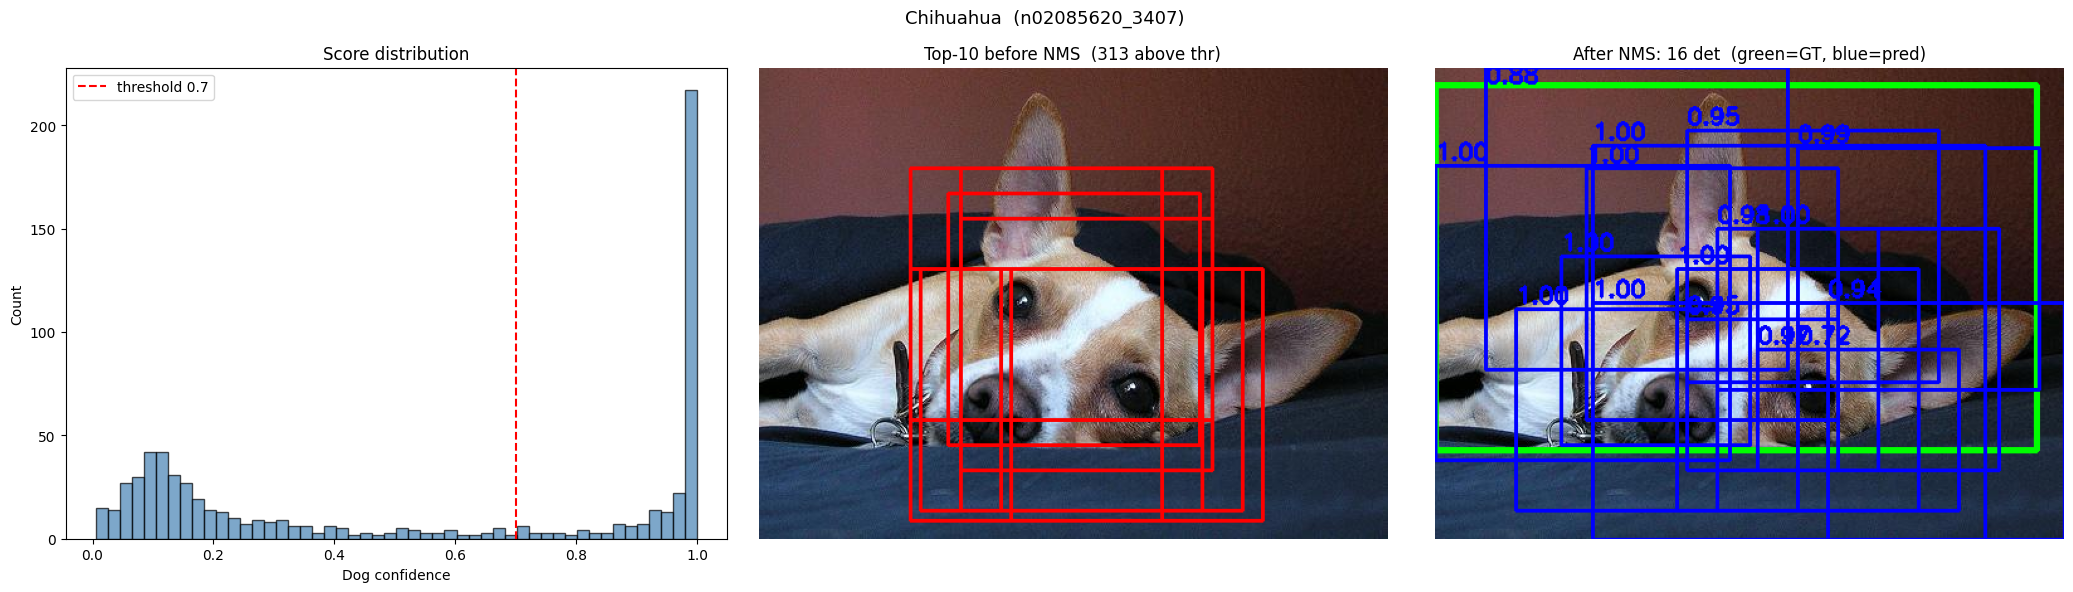

Image: n02085620_9351  Breed: Chihuahua  Size: 500×375
  Candidates generated : 699
  Above threshold      : 206
  After NMS            : 12
  Best score (pre-NMS) : 0.9999


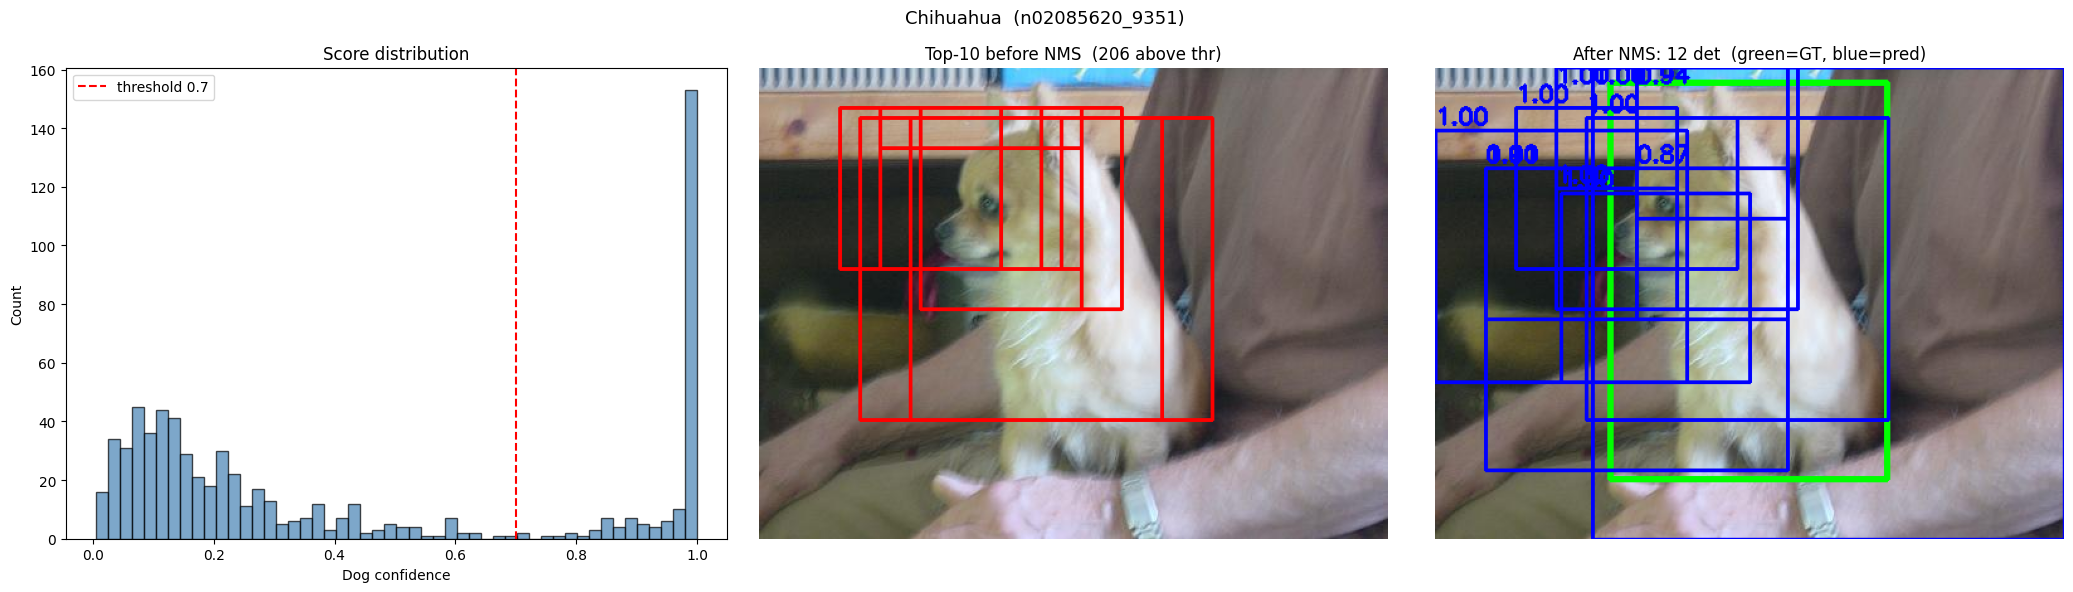

Image: n02085782_1267  Breed: Japanese_spaniel  Size: 150×103
  Candidates generated : 0
  Above threshold      : 0
  After NMS            : 0


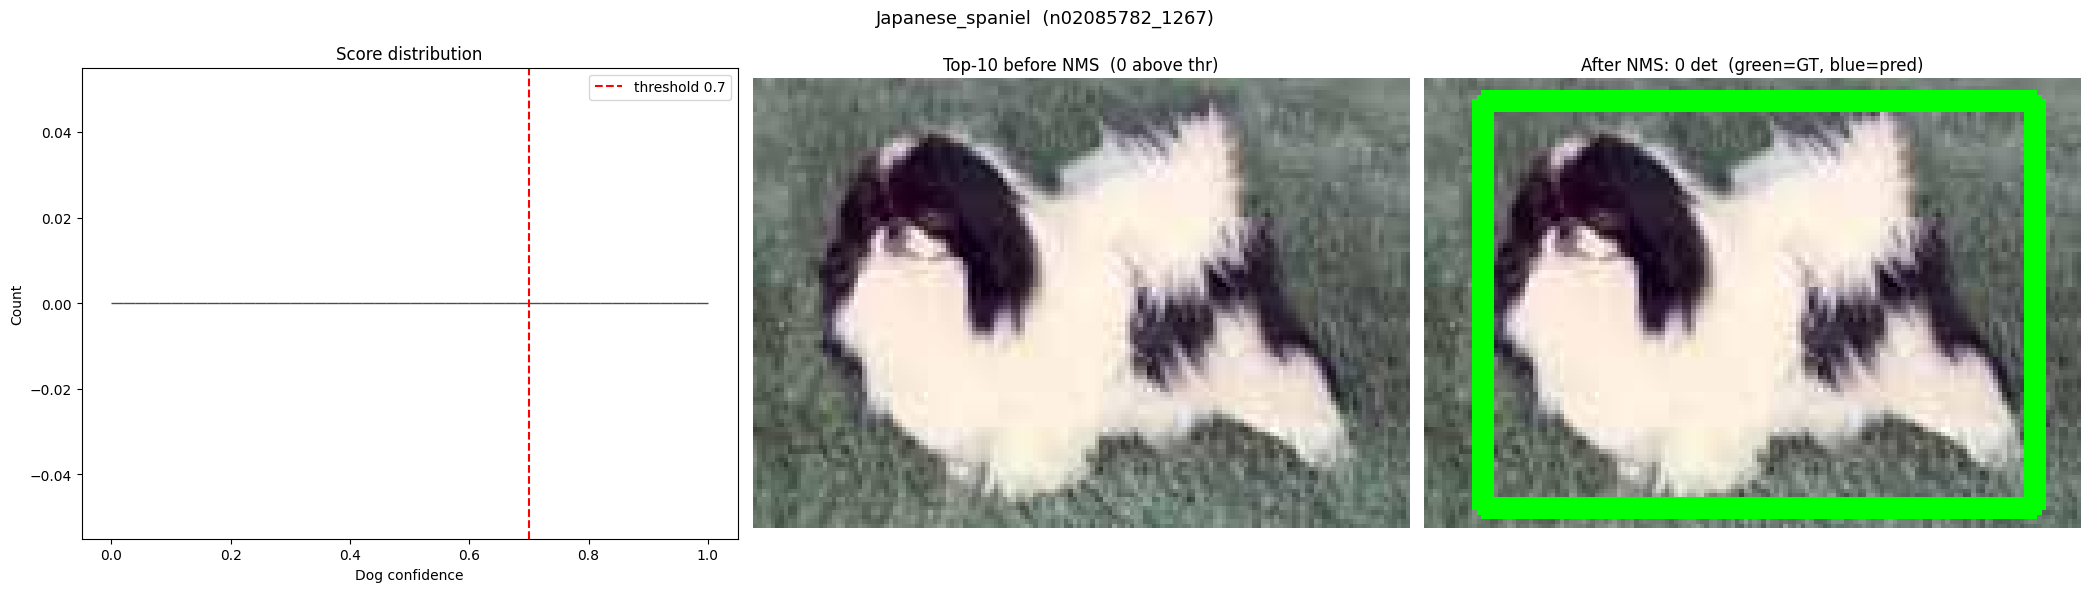

Image: n02085620_5771  Breed: Chihuahua  Size: 281×500
  Candidates generated : 397
  Above threshold      : 233
  After NMS            : 22
  Best score (pre-NMS) : 1.0000


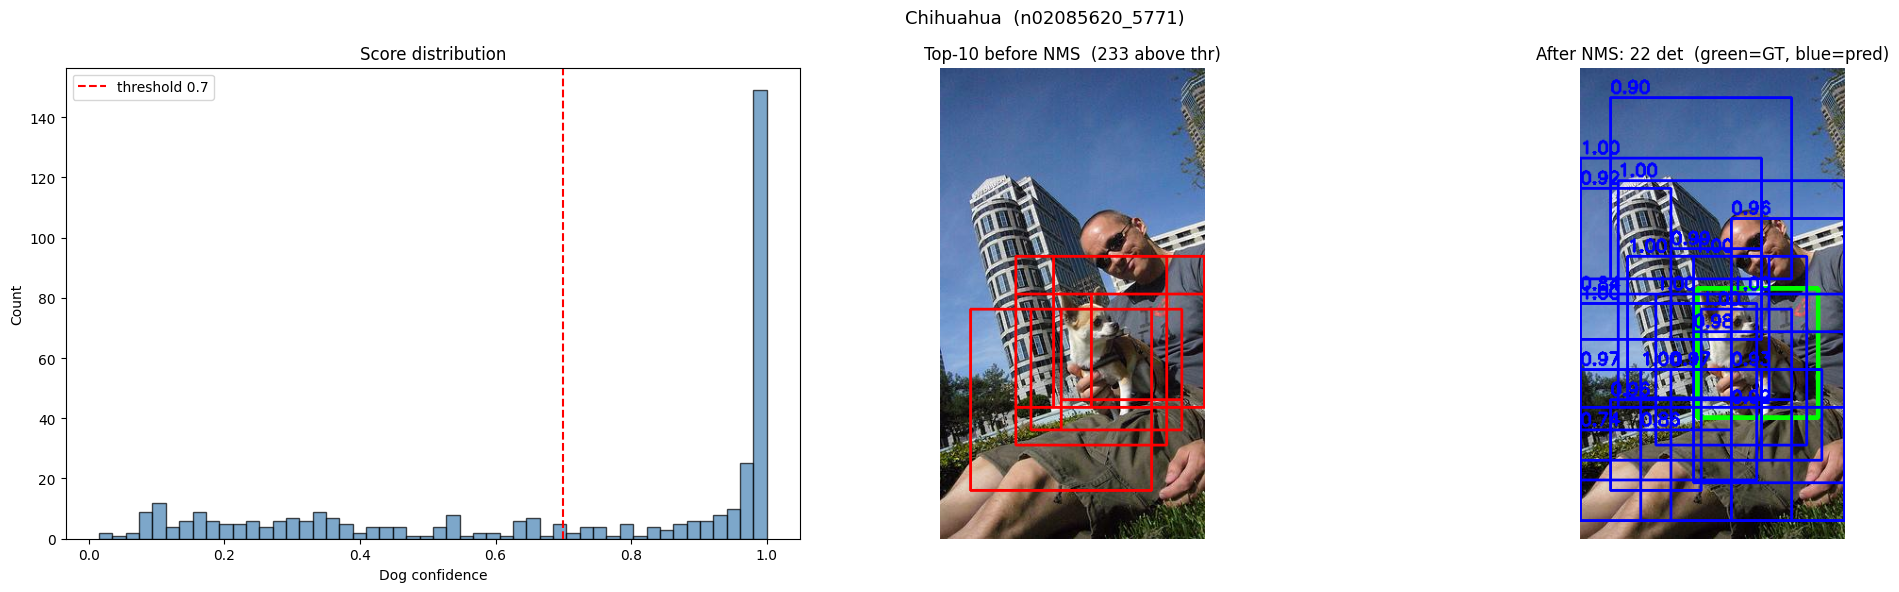

Image: n02085620_949  Breed: Chihuahua  Size: 401×363
  Candidates generated : 504
  Above threshold      : 243
  After NMS            : 16
  Best score (pre-NMS) : 1.0000


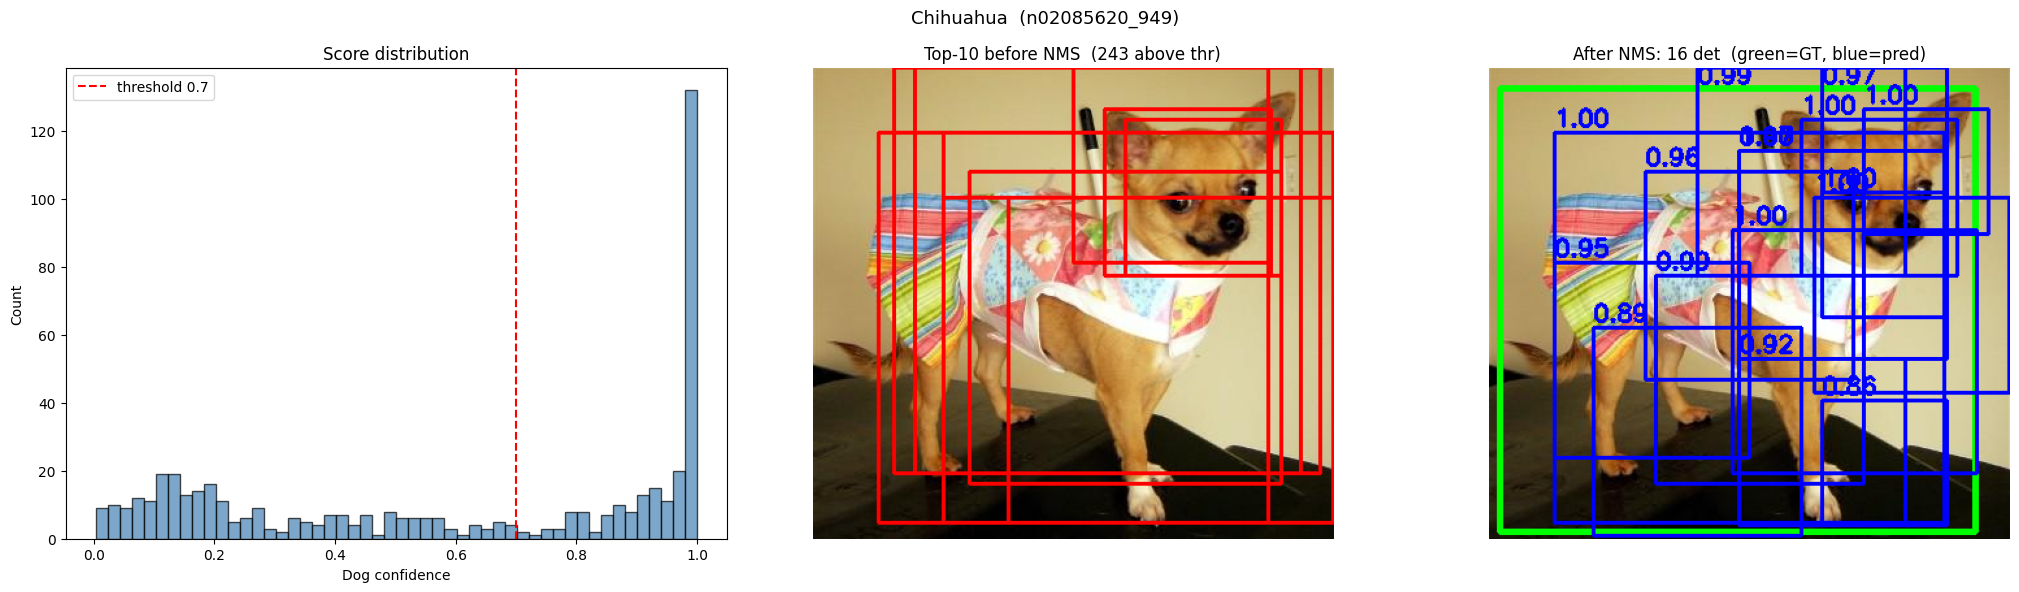

In [14]:
# Run the full detection pipeline on a handful of sample images
NUM_DEMO_IMAGES = 5
demo_indices = random.sample(range(len(stanford_dogs)), min(NUM_DEMO_IMAGES, len(stanford_dogs)))

for idx in demo_indices:
    sample = stanford_dogs[idx]
    image = sample["image"]
    gt_boxes = sample["gt_boxes"]

    print(f"Image: {sample['image_id']}  Breed: {sample['breed']}  "
          f"Size: {image.shape[1]}×{image.shape[0]}")

    detections, debug = detect_dogs_in_image(image, dog_wrapper,
                                              stride=32, score_threshold=0.7)

    print(f"  Candidates generated : {debug['num_candidates']}")
    print(f"  Above threshold      : {debug['num_above_threshold']}")
    print(f"  After NMS            : {debug['num_after_nms']}")

    if debug["top_box_before_nms"]:
        print(f"  Best score (pre-NMS) : {debug['top_box_before_nms']['score']:.4f}")

    visualize_detection_debug(
        image, gt_boxes, detections, debug,
        title=f"{sample['breed']}  ({sample['image_id']})",
    )

# Section 8 – IoU Evaluation & Visualizations

## IoU Evaluation Functions

In [15]:
def compute_iou(box_a, box_b):
    # Compute Intersection-over-Union between two Box namedtuples.
    x1 = max(box_a.x_min, box_b.x_min)
    y1 = max(box_a.y_min, box_b.y_min)
    x2 = min(box_a.x_max, box_b.x_max)
    y2 = min(box_a.y_max, box_b.y_max)
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (box_a.x_max - box_a.x_min) * (box_a.y_max - box_a.y_min)
    area_b = (box_b.x_max - box_b.x_min) * (box_b.y_max - box_b.y_min)
    union = area_a + area_b - inter
    return inter / (union + 1e-6)


def evaluate_image(pred_boxes, gt_boxes):
    # Evaluate top-1 predicted box against ground-truth boxes.

    if not pred_boxes or not gt_boxes:
        return {
            "best_iou": 0.0,
            "best_pred": pred_boxes[0] if pred_boxes else None,
            "matched_gt": gt_boxes[0] if gt_boxes else None,
        }
    top_pred = pred_boxes[0]  # highest score (already sorted by NMS)
    best_iou = 0.0
    matched_gt = gt_boxes[0]
    for gt in gt_boxes:
        iou = compute_iou(top_pred["box"], gt)
        if iou > best_iou:
            best_iou = iou
            matched_gt = gt
    return {"best_iou": best_iou, "best_pred": top_pred, "matched_gt": matched_gt}


def evaluate_dataset(results):
    # Compute summary IoU metrics over all images.
    ious = np.array([r["best_iou"] for r in results])
    return {
        "mean_iou": float(np.mean(ious)),
        "median_iou": float(np.median(ious)),
        "pct_iou_ge_05": float(np.mean(ious >= 0.5) * 100),
        "pct_iou_ge_03": float(np.mean(ious >= 0.3) * 100),
    }


print("Evaluation functions defined.")

Evaluation functions defined.


In [ ]:
# Run detection on entire dataset and evaluate
results = []
n_total = len(stanford_dogs)
progress_step = max(50, n_total // 20)  # ~20 progress lines on large runs

for i, sample in enumerate(stanford_dogs):
    image = sample["image"]
    gt_boxes = sample["gt_boxes"]

    detections, debug = detect_dogs_in_image(image, dog_wrapper,
                                              stride=32, score_threshold=0.7)

    eval_result = evaluate_image(detections, gt_boxes)
    eval_result["image_id"] = sample["image_id"]
    eval_result["breed"] = sample["breed"]
    eval_result["detections"] = detections
    eval_result["gt_boxes"] = gt_boxes
    eval_result["image_idx"] = i  # index into stanford_dogs for later retrieval
    results.append(eval_result)

    if (i + 1) % progress_step == 0 or (i + 1) == n_total:
        print(f"  Processed {i+1}/{n_total} images")

print(f"\nDetection complete: {len(results)} images evaluated.")

In [ ]:
# Compute and display summary metrics
summary = evaluate_dataset(results)
print("IoU Evaluation Summary\n")
print(f"  Mean IoU           : {summary['mean_iou']:.4f}")
print(f"  Median IoU         : {summary['median_iou']:.4f}")
print(f"  IoU >= 0.5         : {summary['pct_iou_ge_05']:.1f}%")
print(f"  IoU >= 0.3         : {summary['pct_iou_ge_03']:.1f}%")
print(f"  Total images       : {len(results)}")

# Save per-image CSV
os.makedirs("outputs", exist_ok=True)
rows = []
for r in results:
    pred_box = r["best_pred"]["box"] if r["best_pred"] else None
    pred_score = r["best_pred"]["score"] if r["best_pred"] else 0.0
    gt_box = r["matched_gt"]
    rows.append({
        "image_id": r["image_id"],
        "pred_box": str(pred_box) if pred_box else "",
        "pred_score": f"{pred_score:.4f}",
        "gt_box": str(gt_box) if gt_box else "",
        "iou": f"{r['best_iou']:.4f}",
        "breed": r["breed"],
    })

df_results = pd.DataFrame(rows)
csv_path = "outputs/per_image_iou_results.csv"
df_results.to_csv(csv_path, index=False)

In [ ]:
# IoU distribution visualization
ious = np.array([r["best_iou"] for r in results])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
ax.hist(ious, bins=20, color="steelblue", edgecolor="black", alpha=0.7)
ax.axvline(0.5, color="red", ls="--", lw=2, label="IoU = 0.5")
ax.axvline(0.3, color="orange", ls="--", lw=2, label="IoU = 0.3")
ax.axvline(np.mean(ious), color="green", ls="-", lw=2, label=f"Mean = {np.mean(ious):.3f}")
ax.set_xlabel("IoU")
ax.set_ylabel("Count")
ax.set_title("IoU Distribution Across Dataset")
ax.legend()

# Sorted IoU curve
ax = axes[1]
ax.plot(np.sort(ious)[::-1], color="steelblue", lw=2)
ax.axhline(0.5, color="red", ls="--", label="IoU = 0.5")
ax.axhline(0.3, color="orange", ls="--", label="IoU = 0.3")
ax.set_xlabel("Image rank (sorted by IoU)")
ax.set_ylabel("IoU")
ax.set_title("IoU Curve (sorted descending)")
ax.legend()

plt.tight_layout()
plt.show()

## Failure Analysis & Qualitative Examples

In [19]:
def draw_evaluation_image(image, pred_box, gt_box, iou, score):
    # Draw GT and prediction with IoU/score text overlay.
    vis = image.copy()
    # GT box in green
    if gt_box is not None:
        cv2.rectangle(vis, (gt_box.x_min, gt_box.y_min),
                      (gt_box.x_max, gt_box.y_max), (0, 255, 0), 3)
    # Predicted box in red
    if pred_box is not None:
        cv2.rectangle(vis, (pred_box.x_min, pred_box.y_min),
                      (pred_box.x_max, pred_box.y_max), (0, 0, 255), 2)
    # Text overlay (white outline + black text for readability)
    text = f"IoU: {iou:.3f}  Score: {score:.3f}"
    cv2.putText(vis, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 4)
    cv2.putText(vis, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)
    return vis

In [ ]:
# Sort results by IoU
sorted_results = sorted(results, key=lambda r: r["best_iou"], reverse=True)
top_10 = sorted_results[:10]       # best IoU
bottom_10 = sorted_results[-10:]   # worst IoU
# Borderline: closest to IoU = 0.5 threshold
borderline_10 = sorted(results, key=lambda r: abs(r["best_iou"] - 0.5))[:10]

# Create output directories
for subdir in ["success", "failure", "borderline"]:
    os.makedirs(f"outputs/qualitative/{subdir}", exist_ok=True)


def save_and_show_group(group, label, subdir):
    # Save annotated images and display as a 2x5 grid.
    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    for ax, r in zip(axes.flat, group):
        sample = stanford_dogs[r["image_idx"]]
        pred_box = r["best_pred"]["box"] if r["best_pred"] else None
        score = r["best_pred"]["score"] if r["best_pred"] else 0.0
        gt_box = r["matched_gt"]

        vis = draw_evaluation_image(sample["image"], pred_box, gt_box,
                                    r["best_iou"], score)

        # Save individual image
        save_path = f"outputs/qualitative/{subdir}/{r['image_id']}.jpg"
        cv2.imwrite(save_path, vis)

        ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{r['breed'][:20]}\nIoU={r['best_iou']:.3f}", fontsize=9)
        ax.axis("off")

    plt.suptitle(f"{label}  (green=GT, red=Pred)", fontsize=14)
    plt.tight_layout()
    plt.show()


save_and_show_group(top_10, "Top 10 — Best IoU (Successes)", "success")
save_and_show_group(bottom_10, "Bottom 10 — Worst IoU (Failures)", "failure")
save_and_show_group(borderline_10, "Borderline — IoU near 0.5", "borderline")

In [ ]:
# Per-breed IoU breakdown
breed_ious = {}
for r in results:
    breed_ious.setdefault(r["breed"], []).append(r["best_iou"])

breed_summary = []
for breed, ious_list in breed_ious.items():
    breed_summary.append({
        "breed": breed,
        "count": len(ious_list),
        "mean_iou": f"{np.mean(ious_list):.3f}",
    })

breed_df = pd.DataFrame(breed_summary).sort_values("mean_iou", ascending=True)
print("Per-breed Mean IoU (worst to best):")
print(breed_df.to_string(index=False))

### Qualitative Discussion

**Successes (high IoU):**
The detector performs best on images where the dog is large relative to the frame, roughly centered, and contrasts clearly against the background. In these cases one of the standard sliding-window scales (96–192 px) closely matches the dog's bounding box and the ResNet classifier confidently scores the patch.

**Failures (low IoU):**
Some failure modes observed:
- Scale mismatch: Very small or very large dogs that do not align well with any window in the image pyramid. The predicted box may cover only part of the dog or include excessive background.
- Cluttered backgrounds: High texture regions (grass, furniture) occasionally produce false-positive patches that survive NMS.
- Multiple dogs: The detector returns the top 1 box, which may match one dog while a different GT box is the evaluation target.
- Unusual poses / occlusion: Dogs lying down, partially hidden, or in non-standard orientations are harder for a classifier trained on centered, upright examples.
- Aspect ratio: Square sliding windows struggle with highly elongated bounding boxes.

**Borderline cases (IoU ~ 0.5):**
These typically show a predicted box that overlaps significantly with the GT but is offset or sized slightly differently — the detector found the correct region but could not precisely localize the full extent of the dog.